In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("../data/processed/final_financial_data.csv")

print("Dataset Shape:", df.shape)
df.head()

Dataset Shape: (9802, 25)


,Transaction_ID,Transaction_Date,Company_Code,Cost_Center,Profit_Center,Account_Category,Transaction_Type,Amount,Budget,Payment_Status,...,Vendor_ID,Tax_Amount,Profit,Approval_Status,Anomaly_Indicator,Year,Month,Quarter,Budget_Variance,Budget_Utilization
0,TX005450,2024-01-17,C003,CC107,PC206,Procurement,Expense,660134.88,870600.30,Pending,...,NaN,115121.44,NaN,Approved,0,2024,1,1,-210465.42,75.825253
1,TX000061,2021-01-21,C001,CC111,PC202,Marketing,Expense,226317.84,255507.62,Paid,...,V040,42898.57,NaN,Approved,0,2021,1,1,-29189.78,88.575769
2,TX007730,2025-10-02,C002,CC105,PC206,Marketing,Expense,381300.39,427732.69,Partially Paid,...,V035,70826.38,NaN,Approved,0,2025,10,4,-46432.30,89.144552
3,TX003695,2023-02-14,C002,CC112,PC204,Procurement,Expense,352712.21,360120.03,Partially Paid,...,V001,62394.66,NaN,Approved,0,2023,2,1,-7407.82,97.942958
4,TX001800,2022-02-25,C005,CC104,PC206,Sales,Revenue,599713.69,603576.07,Paid,...,NaN,109719.59,164961.87,Pending,0,2022,2,1,-3862.38,99.360084


In [3]:
df["Transaction_Date"] = pd.to_datetime(
    df["Transaction_Date"],
    format="mixed",
    dayfirst=True
)

print(df["Transaction_Date"].dtype)

datetime64[ns]


In [4]:
financial_summary = df.groupby("Transaction_Type").agg(
    Transaction_Count=("Transaction_ID", "count"),
    Total_Amount=("Amount", "sum"),
    Average_Amount=("Amount", "mean"),
    Median_Amount=("Amount", "median"),
    Total_Budget=("Budget", "sum"),
    Total_Tax=("Tax_Amount", "sum")
)

financial_summary

,Transaction_Count,Total_Amount,Average_Amount,Median_Amount,Total_Budget,Total_Tax
Transaction_Type,,,,,,
Expense,8255,1.644467e+09,199208.564125,112355.24,1.608947e+09,2.191424e+08
Revenue,1547,9.933833e+08,642135.324855,559752.87,9.345203e+08,1.551611e+08


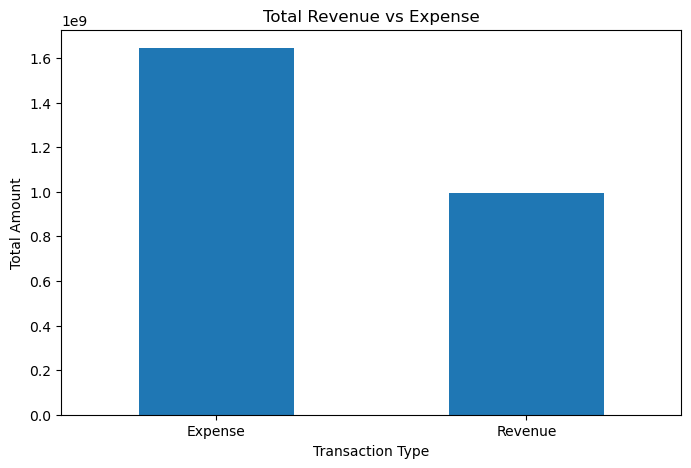

In [5]:
transaction_totals = df.groupby("Transaction_Type")["Amount"].sum()

plt.figure(figsize=(8, 5))

transaction_totals.plot(kind="bar")

plt.title("Total Revenue vs Expense")
plt.xlabel("Transaction Type")
plt.ylabel("Total Amount")
plt.xticks(rotation=0)

plt.show()

In [6]:
yearly_financials = df.groupby(
    ["Year", "Transaction_Type"]
)["Amount"].sum().unstack()

yearly_financials

Transaction_Type,Expense,Revenue
Year,,
2021,2.449176e+08,1.443689e+08
2022,2.792820e+08,1.536363e+08
2023,3.216218e+08,1.896244e+08
2024,3.694995e+08,2.310507e+08
2025,4.291458e+08,2.747031e+08


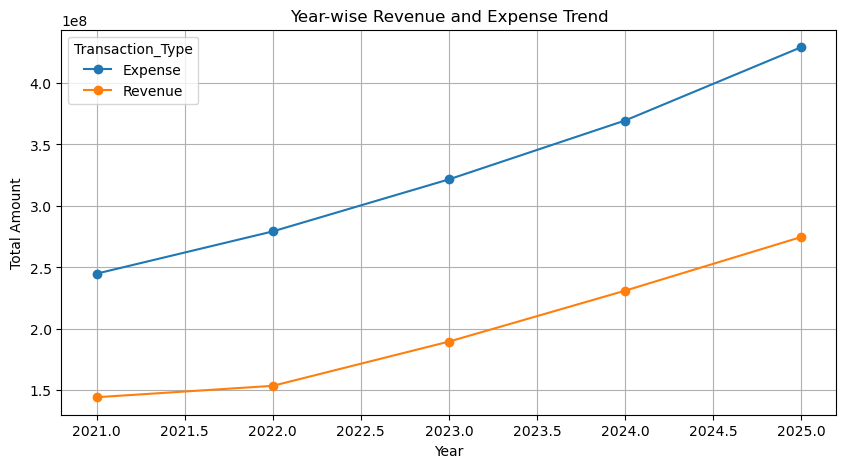

In [7]:
yearly_financials.plot(
    kind="line",
    marker="o",
    figsize=(10, 5)
)

plt.title("Year-wise Revenue and Expense Trend")
plt.xlabel("Year")
plt.ylabel("Total Amount")
plt.grid(True)

plt.show()

In [8]:
department_expenses = (
    df[df["Transaction_Type"] == "Expense"]
    .groupby("Department")["Amount"]
    .sum()
    .sort_values(ascending=False)
)

department_expenses

Department
Operations        3.475406e+08
IT                3.184716e+08
Marketing         2.654979e+08
Sales             2.326824e+08
Finance           1.995288e+08
Procurement       1.585050e+08
HR                6.328959e+07
Administration    5.895076e+07
Name: Amount, dtype: float64

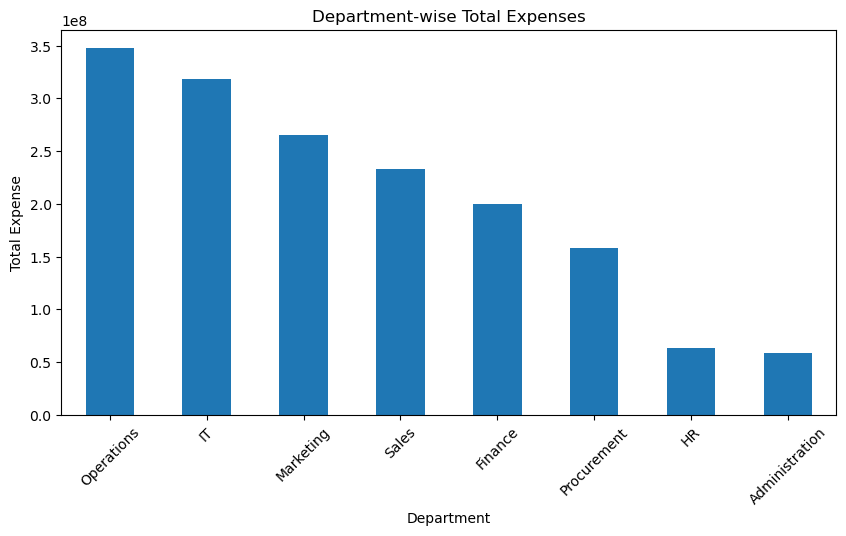

In [9]:
plt.figure(figsize=(10, 5))

department_expenses.plot(kind="bar")

plt.title("Department-wise Total Expenses")
plt.xlabel("Department")
plt.ylabel("Total Expense")
plt.xticks(rotation=45)

plt.show()

In [10]:
category_expenses = (
    df[df["Transaction_Type"] == "Expense"]
    .groupby("Account_Category")["Amount"]
    .sum()
    .sort_values(ascending=False)
)

category_expenses

Account_Category
Procurement        4.632552e+08
Marketing          2.632312e+08
IT                 2.394090e+08
Maintenance        1.351157e+08
Salaries           1.295466e+08
Other              1.234561e+08
Logistics          1.159349e+08
Travel             8.038451e+07
Office Supplies    5.044301e+07
Utilities          4.369052e+07
Name: Amount, dtype: float64

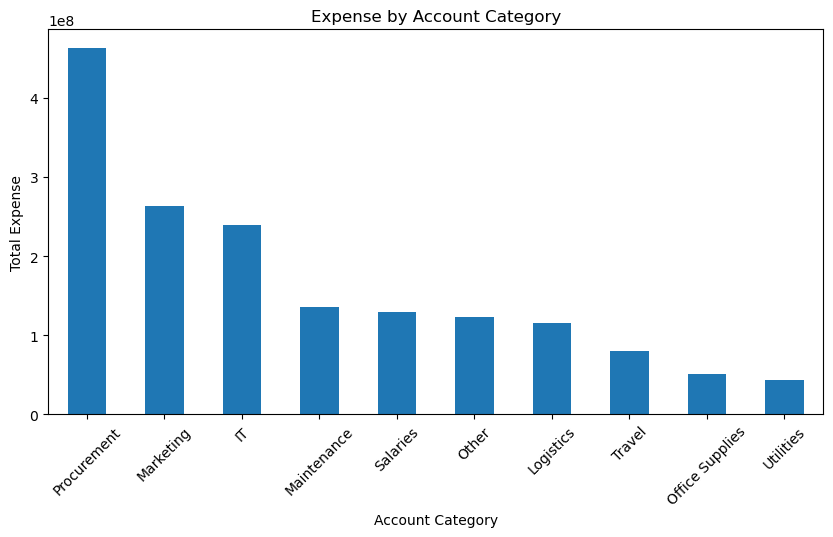

In [11]:
plt.figure(figsize=(10, 5))

category_expenses.plot(kind="bar")

plt.title("Expense by Account Category")
plt.xlabel("Account Category")
plt.ylabel("Total Expense")
plt.xticks(rotation=45)

plt.show()

In [12]:
budget_analysis = (
    df[df["Transaction_Type"] == "Expense"]
    .groupby("Year")
    .agg(
        Actual_Expense=("Amount", "sum"),
        Budget=("Budget", "sum")
    )
)

budget_analysis["Variance"] = (
    budget_analysis["Actual_Expense"] -
    budget_analysis["Budget"]
)

budget_analysis

,Actual_Expense,Budget,Variance
Year,,,
2021,2.449176e+08,2.383578e+08,6559811.58
2022,2.792820e+08,2.792917e+08,-9618.66
2023,3.216218e+08,3.168137e+08,4808109.39
2024,3.694995e+08,3.649128e+08,4586755.85
2025,4.291458e+08,4.095709e+08,19574886.68


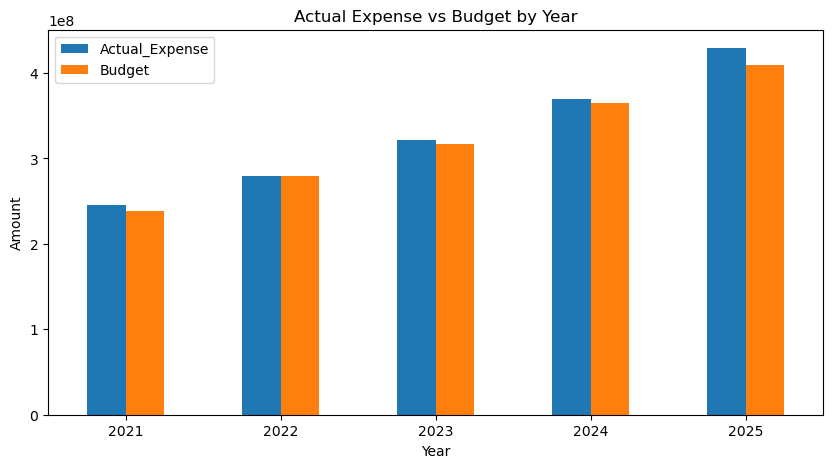

In [13]:
budget_analysis[["Actual_Expense", "Budget"]].plot(
    kind="bar",
    figsize=(10, 5)
)

plt.title("Actual Expense vs Budget by Year")
plt.xlabel("Year")
plt.ylabel("Amount")
plt.xticks(rotation=0)

plt.show()

In [14]:
monthly_financials = (
    df.groupby(
        [df["Transaction_Date"].dt.to_period("M"), "Transaction_Type"]
    )["Amount"]
    .sum()
    .unstack()
)

monthly_financials.head()

Transaction_Type,Expense,Revenue
Transaction_Date,,
2021-01,14709639.29,8437831.52
2021-02,14371577.45,11672693.16
2021-03,29949213.44,15201713.77
2021-04,17251021.57,11762185.49
2021-05,18282795.56,9830046.88


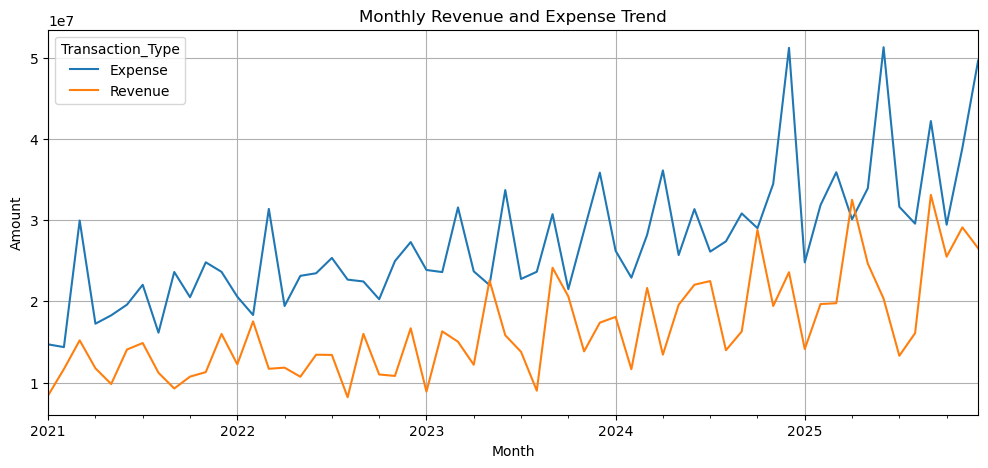

In [15]:
monthly_financials.plot(
    kind="line",
    figsize=(12, 5)
)

plt.title("Monthly Revenue and Expense Trend")
plt.xlabel("Month")
plt.ylabel("Amount")
plt.grid(True)

plt.show()

In [16]:
quarterly_financials = (
    df.groupby(
        ["Year", "Quarter", "Transaction_Type"]
    )["Amount"]
    .sum()
    .unstack()
)

quarterly_financials

Transaction_Type       Expense      Revenue
Year Quarter                               
2021 1            5.903043e+07  35312238.45
     2            5.512915e+07  35665186.89
     3            6.180792e+07  35368918.08
     4            6.895008e+07  38022513.64
2022 1            7.026795e+07  41495169.41
     2            6.603270e+07  36006004.02
     3            7.046779e+07  37615905.54
     4            7.251360e+07  38519222.45
2023 1            7.902297e+07  40244166.95
     2            7.939825e+07  50607386.76
     3            7.713178e+07  46936181.33
     4            8.606878e+07  51836659.24
2024 1            7.733224e+07  51392456.07
     2            9.316614e+07  55070820.21
     3            8.432670e+07  52779298.49
     4            1.146744e+08  71808158.04
2025 1            9.252523e+07  53580322.02
     2            1.152923e+08  77476651.85
     3            1.033778e+08  62505211.06
     4            1.179504e+08  81140877.05

In [17]:
profit_analysis = (
    df[df["Transaction_Type"] == "Revenue"]
    .groupby("Year")["Profit"]
    .agg(
        Total_Profit="sum",
        Average_Profit="mean"
    )
)

profit_analysis

,Total_Profit,Average_Profit
Year,,
2021,43750924.17,159674.905730
2022,48302260.02,163183.310878
2023,52560286.21,175200.954033
2024,67536156.72,205277.072097
2025,75988925.23,218358.980546


In [18]:
profit_analysis["Profit_Margin"] = (
    profit_analysis["Total_Profit"] /
    df[df["Transaction_Type"] == "Revenue"]
    .groupby("Year")["Amount"]
    .sum()
) * 100

profit_analysis

,Total_Profit,Average_Profit,Profit_Margin
Year,,,
2021,43750924.17,159674.905730,30.304960
2022,48302260.02,163183.310878,31.439354
2023,52560286.21,175200.954033,27.718104
2024,67536156.72,205277.072097,29.230012
2025,75988925.23,218358.980546,27.662205


In [19]:
payment_analysis = (
    df.groupby("Payment_Status")["Amount"]
    .agg(
        Transaction_Count="count",
        Total_Amount="sum"
    )
    .sort_values("Total_Amount", ascending=False)
)

payment_analysis

,Transaction_Count,Total_Amount
Payment_Status,,
Paid,6178,1.595559e+09
Pending,1529,4.562346e+08
Overdue,1083,3.232930e+08
Partially Paid,1012,2.627635e+08


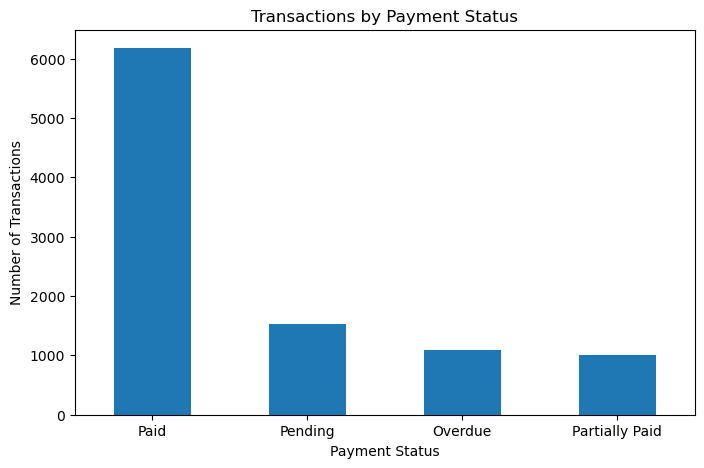

In [20]:
plt.figure(figsize=(8, 5))

payment_analysis["Transaction_Count"].plot(
    kind="bar"
)

plt.title("Transactions by Payment Status")
plt.xlabel("Payment Status")
plt.ylabel("Number of Transactions")
plt.xticks(rotation=0)

plt.show()

In [21]:
approval_analysis = (
    df.groupby("Approval_Status")["Amount"]
    .agg(
        Transaction_Count="count",
        Total_Amount="sum"
    )
    .sort_values("Total_Amount", ascending=False)
)

approval_analysis

,Transaction_Count,Total_Amount
Approval_Status,,
Approved,7984,2.144048e+09
Pending,910,2.464214e+08
Rejected,472,1.282218e+08
Under Review,436,1.191591e+08


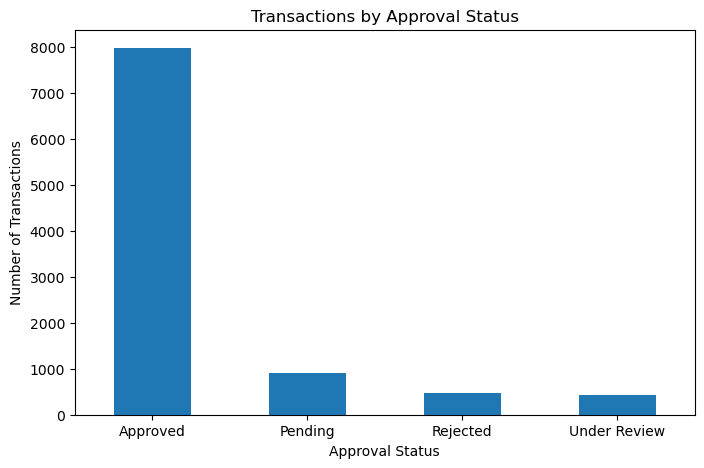

In [22]:
plt.figure(figsize=(8, 5))

approval_analysis["Transaction_Count"].plot(
    kind="bar"
)

plt.title("Transactions by Approval Status")
plt.xlabel("Approval Status")
plt.ylabel("Number of Transactions")
plt.xticks(rotation=0)

plt.show()

In [23]:
anomaly_analysis = (
    df.groupby("Anomaly_Indicator")["Amount"]
    .agg(
        Transaction_Count="count",
        Total_Amount="sum",
        Average_Amount="mean"
    )
)

anomaly_analysis

,Transaction_Count,Total_Amount,Average_Amount
Anomaly_Indicator,,,
0,9607,2.473812e+09,257501.033629
1,195,1.640376e+08,841218.535026


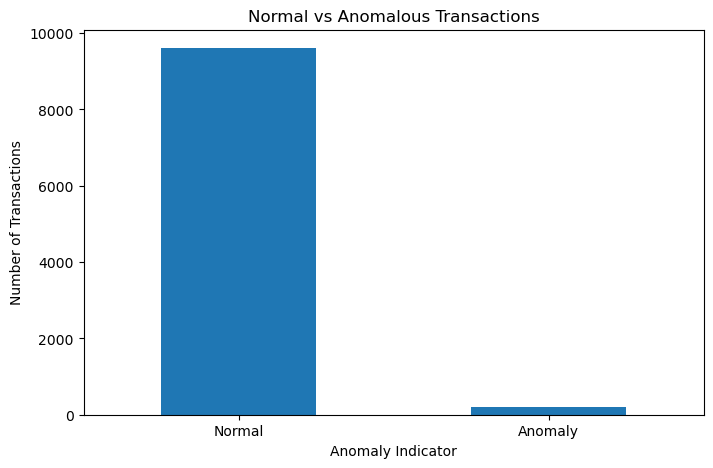

In [24]:
plt.figure(figsize=(8, 5))

df["Anomaly_Indicator"].value_counts().sort_index().plot(
    kind="bar"
)

plt.title("Normal vs Anomalous Transactions")
plt.xlabel("Anomaly Indicator")
plt.ylabel("Number of Transactions")
plt.xticks(
    ticks=[0, 1],
    labels=["Normal", "Anomaly"],
    rotation=0
)

plt.show()

In [25]:
company_analysis = (
    df.groupby(["Company_Code", "Transaction_Type"])["Amount"]
    .sum()
    .unstack()
)

company_analysis

Transaction_Type,Expense,Revenue
Company_Code,,
C001,5.501375e+08,3.356596e+08
C002,4.266746e+08,2.724975e+08
C003,3.418821e+08,2.057285e+08
C004,2.375315e+08,1.230050e+08
C005,8.824110e+07,5.649274e+07


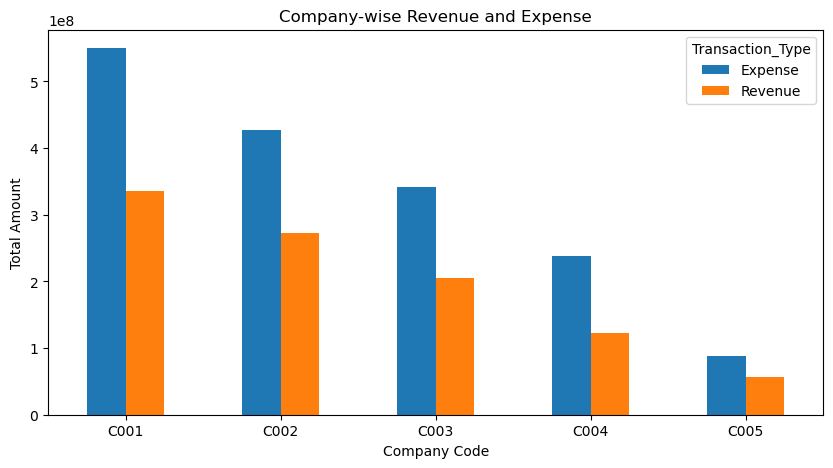

In [26]:
company_analysis.plot(
    kind="bar",
    figsize=(10, 5)
)

plt.title("Company-wise Revenue and Expense")
plt.xlabel("Company Code")
plt.ylabel("Total Amount")
plt.xticks(rotation=0)

plt.show()

In [27]:
total_revenue = df.loc[
    df["Transaction_Type"] == "Revenue",
    "Amount"
].sum()

total_expense = df.loc[
    df["Transaction_Type"] == "Expense",
    "Amount"
].sum()

total_profit = df["Profit"].sum()

total_budget = df.loc[
    df["Transaction_Type"] == "Expense",
    "Budget"
].sum()

total_transactions = len(df)

anomaly_count = df["Anomaly_Indicator"].sum()

kpi_summary = pd.DataFrame({
    "KPI": [
        "Total Transactions",
        "Total Revenue",
        "Total Expense",
        "Total Profit",
        "Total Expense Budget",
        "Anomalous Transactions"
    ],
    "Value": [
        total_transactions,
        total_revenue,
        total_expense,
        total_profit,
        total_budget,
        anomaly_count
    ]
})

kpi_summary

,KPI,Value
0,Total Transactions,9.802000e+03
1,Total Revenue,9.933833e+08
2,Total Expense,1.644467e+09
3,Total Profit,2.881386e+08
4,Total Expense Budget,1.608947e+09
5,Anomalous Transactions,1.950000e+02


In [28]:
numeric_columns = [
    "Amount",
    "Budget",
    "Quantity",
    "Tax_Amount",
    "Profit",
    "Budget_Variance",
    "Budget_Utilization"
]

correlation_matrix = df[numeric_columns].corr()

correlation_matrix

,Amount,Budget,Quantity,Tax_Amount,Profit,Budget_Variance,Budget_Utilization
Amount,1.000000,0.693407,0.532231,0.707036,0.548832,0.723478,0.418342
Budget,0.693407,1.000000,0.730705,0.850906,0.659809,0.004237,-0.037585
Quantity,0.532231,0.730705,1.000000,0.680589,0.462873,0.038562,0.001191
Tax_Amount,0.707036,0.850906,0.680589,1.000000,0.841909,0.165997,0.076635
Profit,0.548832,0.659809,0.462873,0.841909,1.000000,0.257748,0.264250
Budget_Variance,0.723478,0.004237,0.038562,0.165997,0.257748,1.000000,0.616595
Budget_Utilization,0.418342,-0.037585,0.001191,0.076635,0.264250,0.616595,1.000000


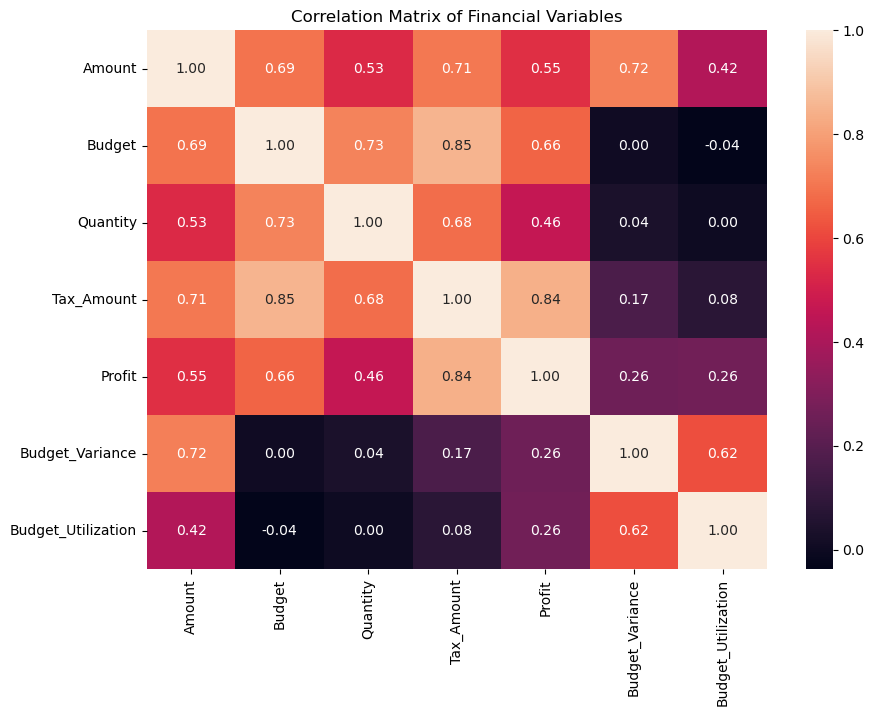

In [29]:
plt.figure(figsize=(10, 7))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f"
)

plt.title("Correlation Matrix of Financial Variables")

plt.show()